In [2]:
import pandas as pd
from tqdm import tqdm
import json,re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


def read_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            try:
                json_object = json.loads(line.strip())
                data.append(json_object)
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON: {e}")
                continue
                # 如果选择抛出异常，使用下面这行
                # raise
    return data

def is_gt_data(data_list):
    return all(
        data['is_correct'] == 'Y' or (data['is_correct'] == 'N' and data['human_action'])
        for data in data_list
    )

def is_trajectory_data(data_list):
    if data_list[-1]['is_correct'] == 'Y' and data_list[-1]['action'] == 'Stop':
        return True
    if data_list[-1]['is_correct'] == 'N' and data_list[-1]['human_action'] == 'Stop':
        return True
    return False

def is_trajectory_data_open(data_list):
    if data_list[-1]["standard_action"]['action'] == "Terminate":
        return True
    return False


def copy_trajectory_images(input_file_path, image_folder, paper_folder):

    if not os.path.exists(input_file_path):
        raise FileNotFoundError(f"Input file not found: {input_file_path}")
    if not os.path.exists(image_folder):
        raise FileNotFoundError(f"Image folder not found: {image_folder}")

    os.makedirs(paper_folder, exist_ok=True)
    
    try:
        all_data = read_jsonl(input_file_path)
        draw_data = all_data[-2]  # 获取倒数第二条数据
    except Exception as e:
        print(f"Error reading data: {e}")
        return
    
    draw_images = [data['screenshot'].split("/")[-1] for data in draw_data['data']]
    
    for image in draw_images:
        old_image_path = os.path.join(image_folder, image)
        paper_image_path = os.path.join(paper_folder, image)
        
        # 检查源文件是否存在
        if not os.path.exists(old_image_path):
            print(f"Warning: Source image not found: {old_image_path}")
            continue
            
        try:
            shutil.copy(old_image_path, paper_image_path)
            print(f"Successfully copied: {image}")
        except Exception as e:
            print(f"Error copying {image}: {e}")
# available_gt_data_5_10_steps = [data for data in available_data_5_10_steps if is_gt_data(data['data'])]

# 中文到英文的映射字典
app_name_mapping = {
    '应用商店': 'App Store',
    '夸克': 'Quark',
    '快手': 'Kuaishou',
    '腾讯地图': 'Tencent Maps',
    '拼多多': 'Pinduoduo',
    '百度': 'Baidu',
    '哔哩哔哩': 'Bilibili',
    '大众点评': 'Dianping',
    '美团': 'Meituan',
    '支付宝': 'Alipay',
    '京东': 'JD',
    '飞猪': 'Fliggy',
    '闲鱼': 'Idle Fish',
    '淘宝': 'Taobao',
    '小红书': 'Xiaohongshu',
    '浏览器': 'Browser',
    '计算器': 'Calculator',
    '微信': 'WeChat',
    '高德地图': 'Amap',
    '瑞幸咖啡': 'Luckin Coffee',
    '笔记': 'Notes',
    '饿了么': 'Eleme',
    '转转': 'Zhuanzhuan',
    '手机系统': 'Mobile System',
    '百度地图': 'Baidu Maps',
    '抖音': 'Douyin',
    '日历': 'Calendar',
    '天气': 'Weather'
}

App distribution based on data num:
          app_name  data num
0          Alipay         3
1            Amap       227
2       App Store        11
3           Baidu       160
4      Baidu Maps       191
5        Bilibili       148
6         Browser       174
7      Calculator       195
8        Calendar       162
9        Dianping         4
10         Douyin       152
11          Eleme       193
12         Fliggy       191
13      Idle Fish        27
14             JD       200
15       Kuaishou       136
16  Luckin Coffee        97
17        Meituan       252
18  Mobile System         7
19          Notes        64
20      Pinduoduo       180
21          Quark       181
22         Taobao       221
23   Tencent Maps       231
24         WeChat        33
25        Weather       159
26    Xiaohongshu       296
27     Zhuanzhuan         4


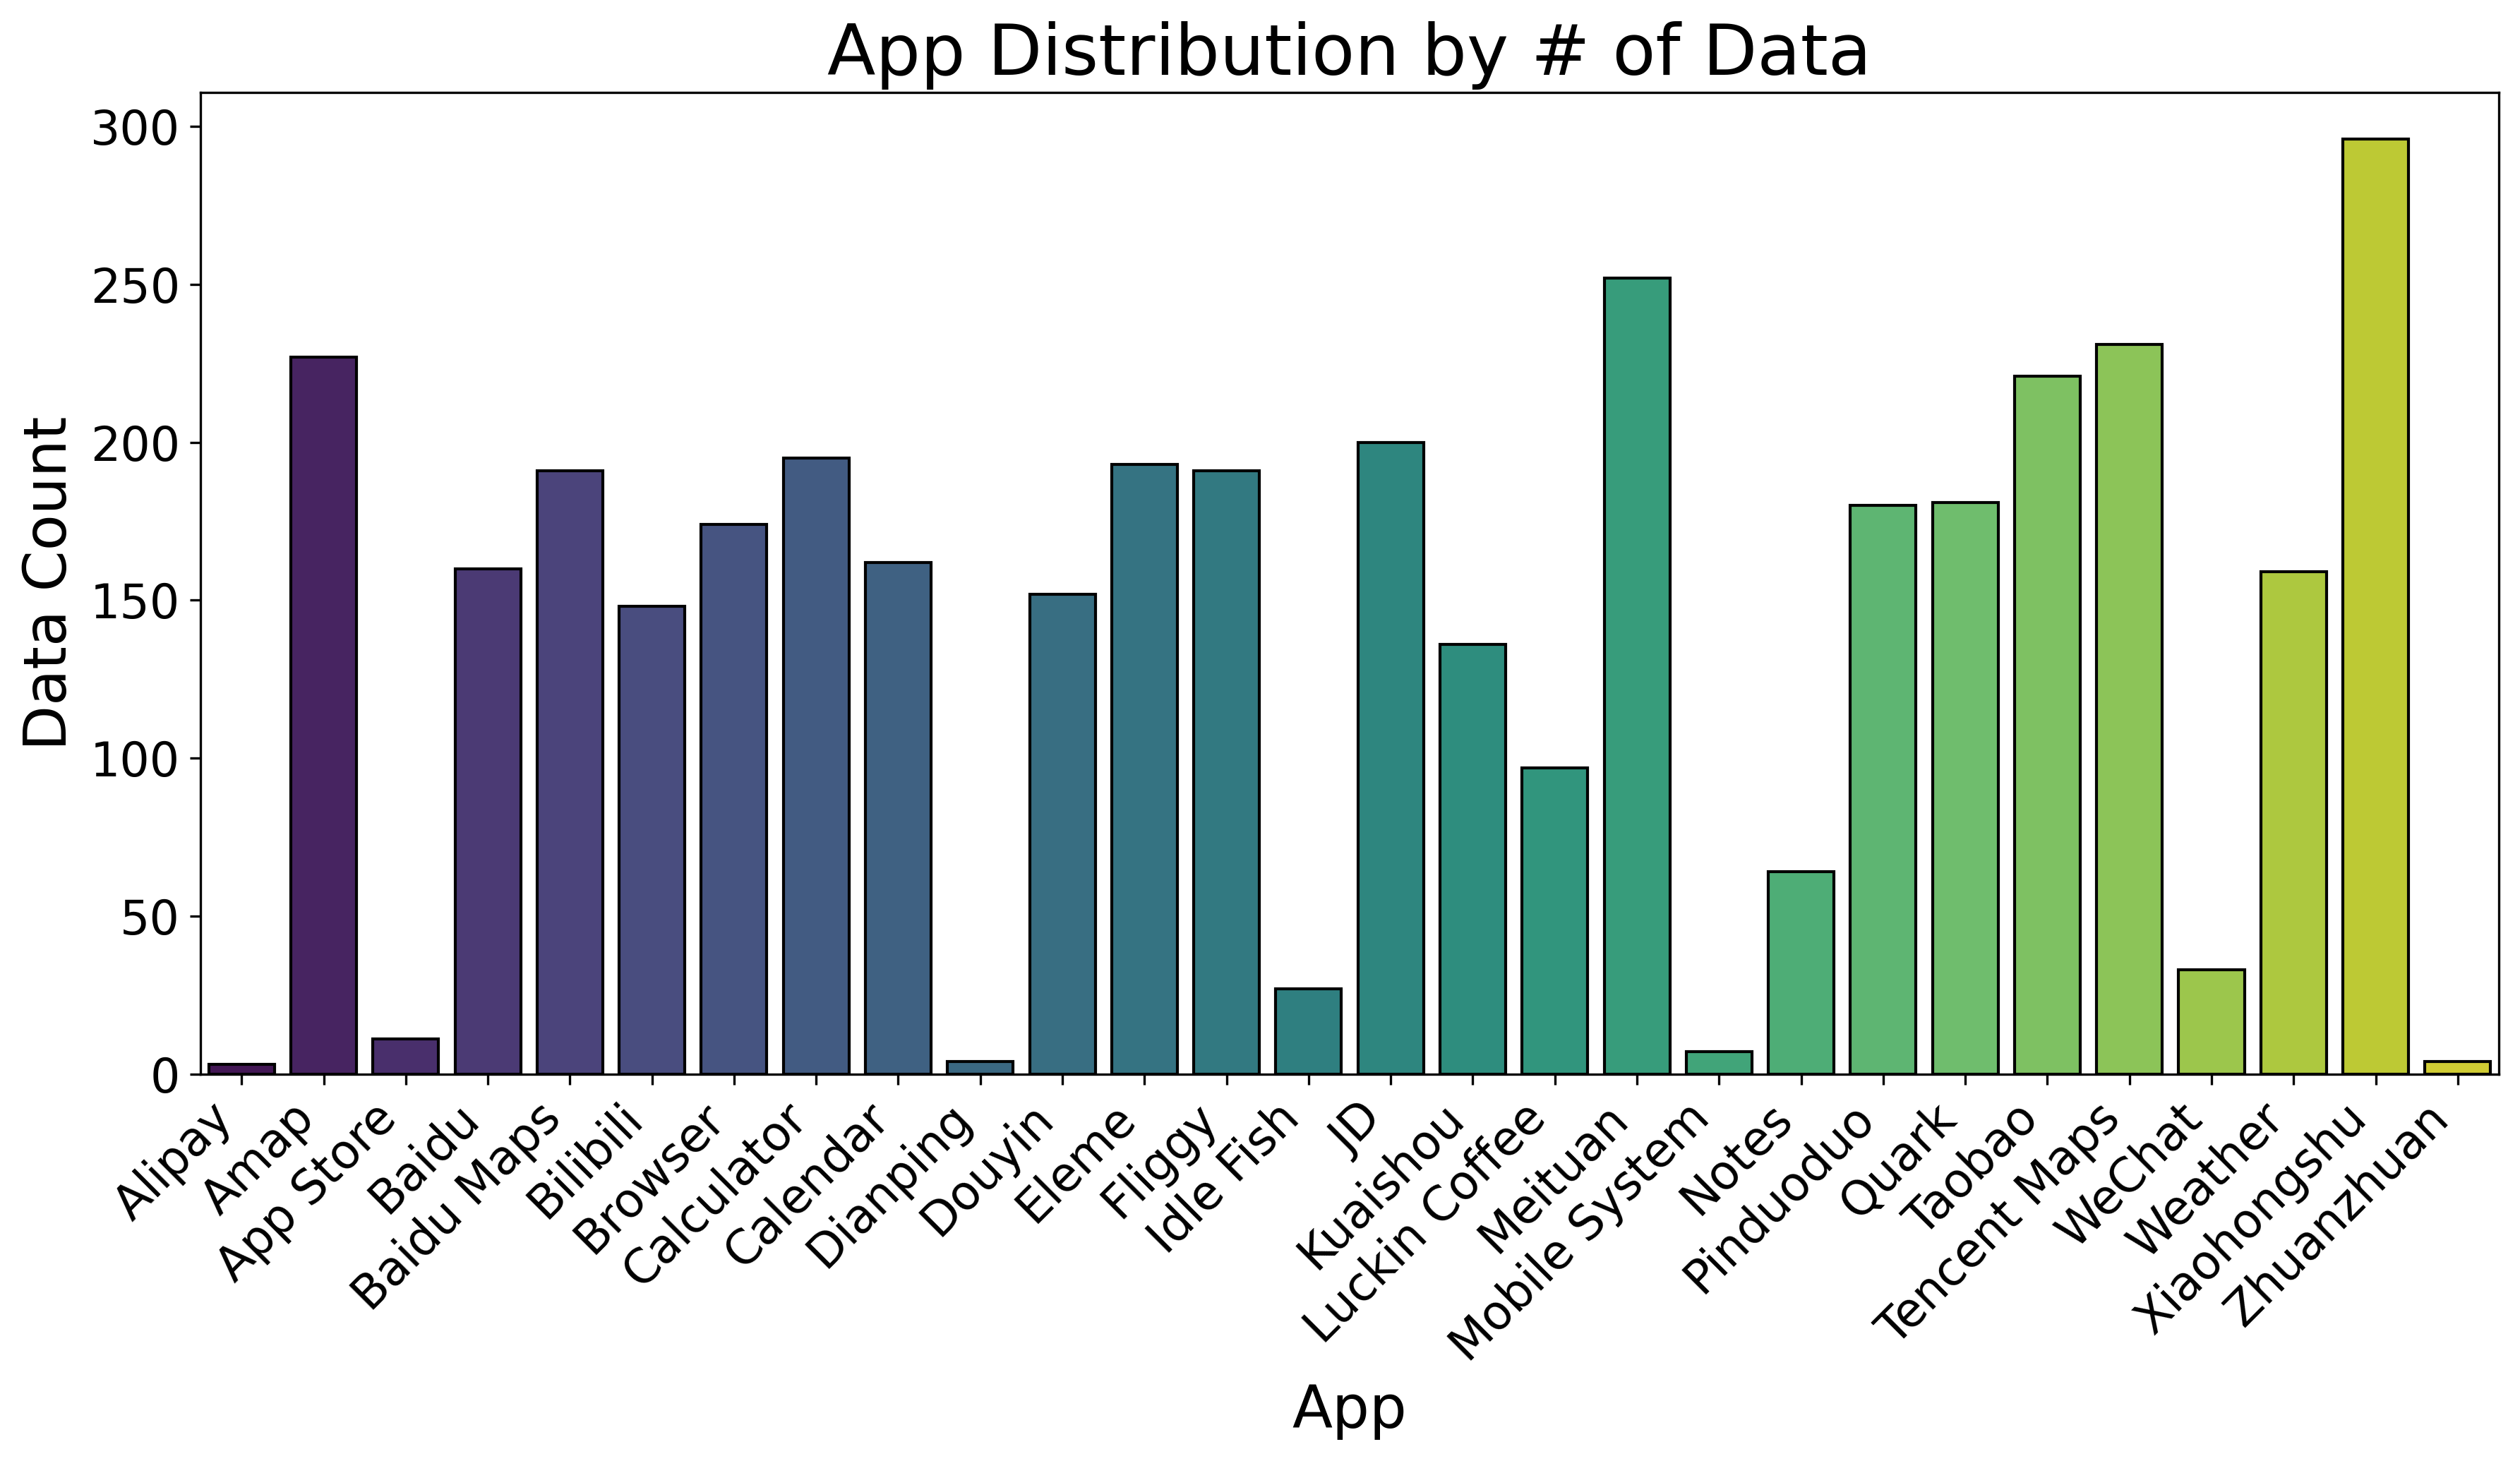

total trajectory num: 291
App distribution based on trajectory num:
          app_name  trajectory num
0            Amap              14
1       App Store               2
2           Baidu              12
3      Baidu Maps              11
4        Bilibili              11
5         Browser               1
6      Calculator              10
7        Calendar              14
8          Douyin              21
9           Eleme              36
10         Fliggy               5
11      Idle Fish               1
12             JD               5
13       Kuaishou              11
14  Luckin Coffee               3
15        Meituan              23
16          Notes              10
17      Pinduoduo               4
18          Quark              12
19         Taobao              21
20   Tencent Maps              24
21         WeChat               3
22        Weather              19
23    Xiaohongshu              18


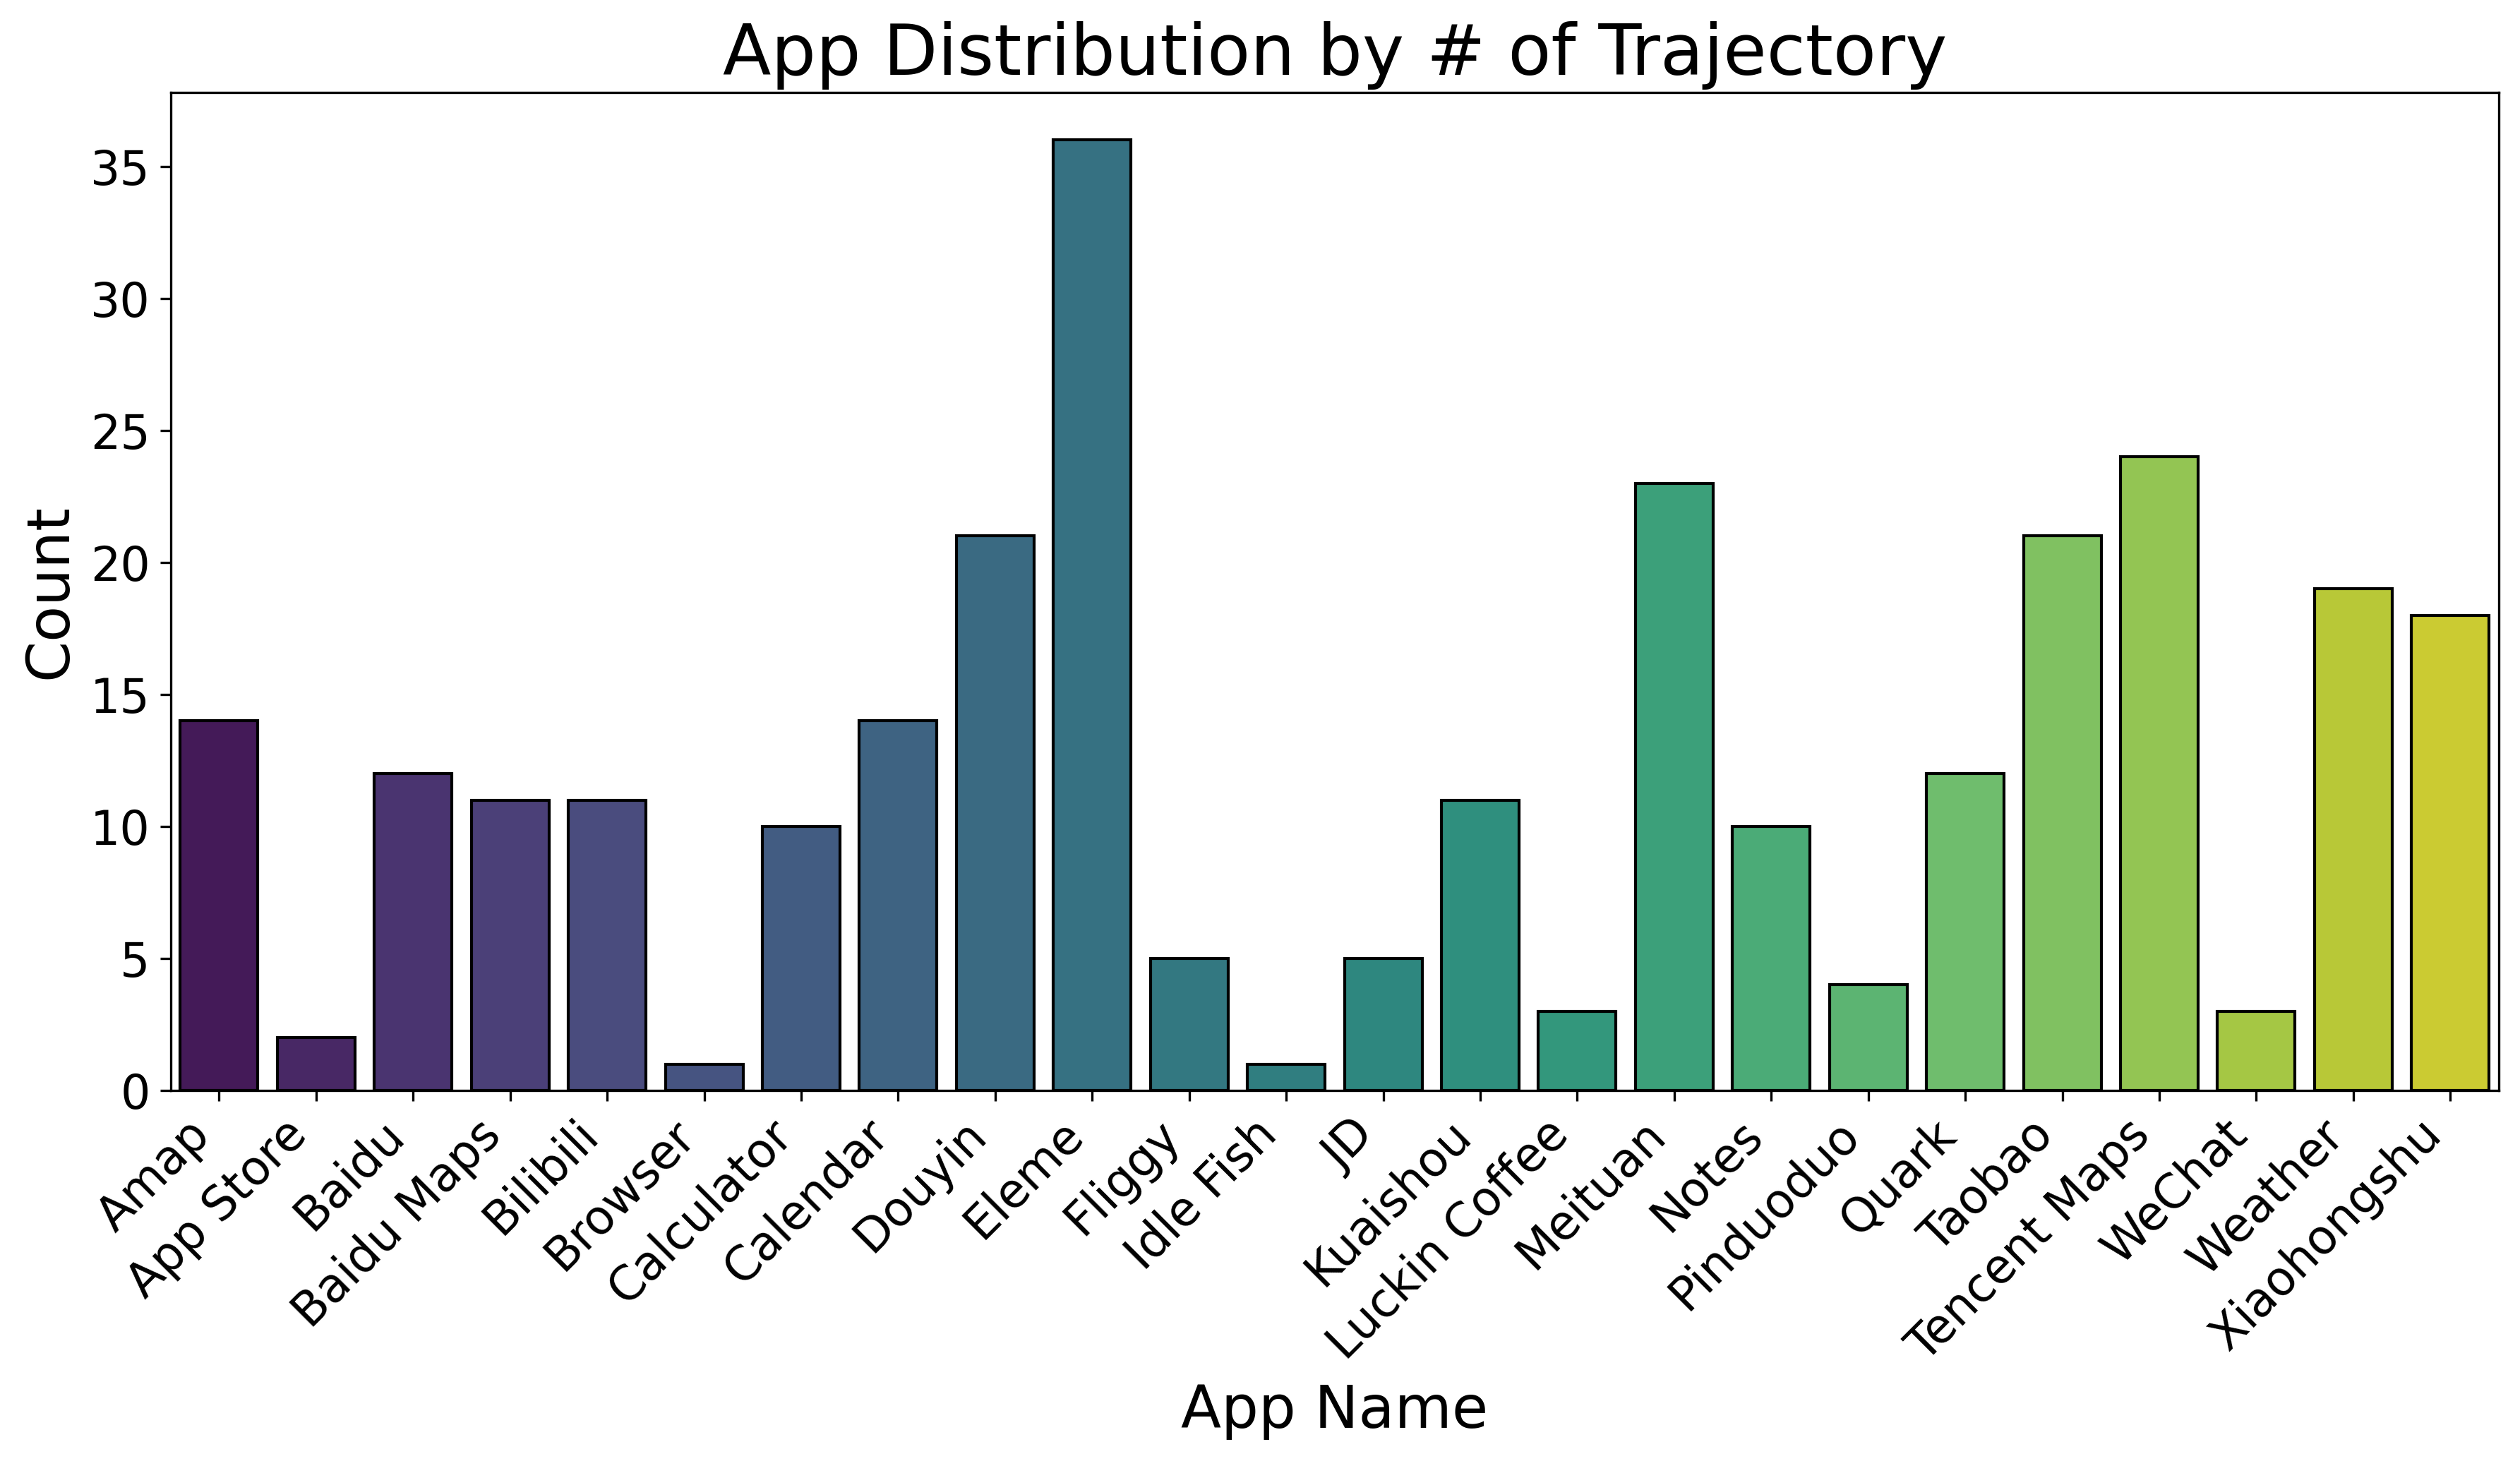

App distribution based on trajectory length:
               app      mean  min  max
0            Amap  5.142857    3    9
1       App Store  2.000000    2    2
2           Baidu  4.583333    3    6
3      Baidu Maps  6.090909    4    8
4        Bilibili  4.818182    3    7
5         Browser  7.000000    7    7
6      Calculator  6.100000    3    9
7        Calendar  3.785714    2    7
8          Douyin  3.714286    3    6
9           Eleme  4.333333    2    6
10         Fliggy  6.000000    5    9
11      Idle Fish  6.000000    6    6
12             JD  7.000000    5    9
13       Kuaishou  4.909091    3    7
14  Luckin Coffee  8.333333    7   10
15        Meituan  6.565217    4    8
16          Notes  3.600000    2    6
17      Pinduoduo  6.500000    5    9
18          Quark  5.166667    2    7
19         Taobao  5.761905    4    9
20   Tencent Maps  5.375000    2    8
21         WeChat  6.000000    5    7
22        Weather  3.105263    2    7
23    Xiaohongshu  7.222222    4   10


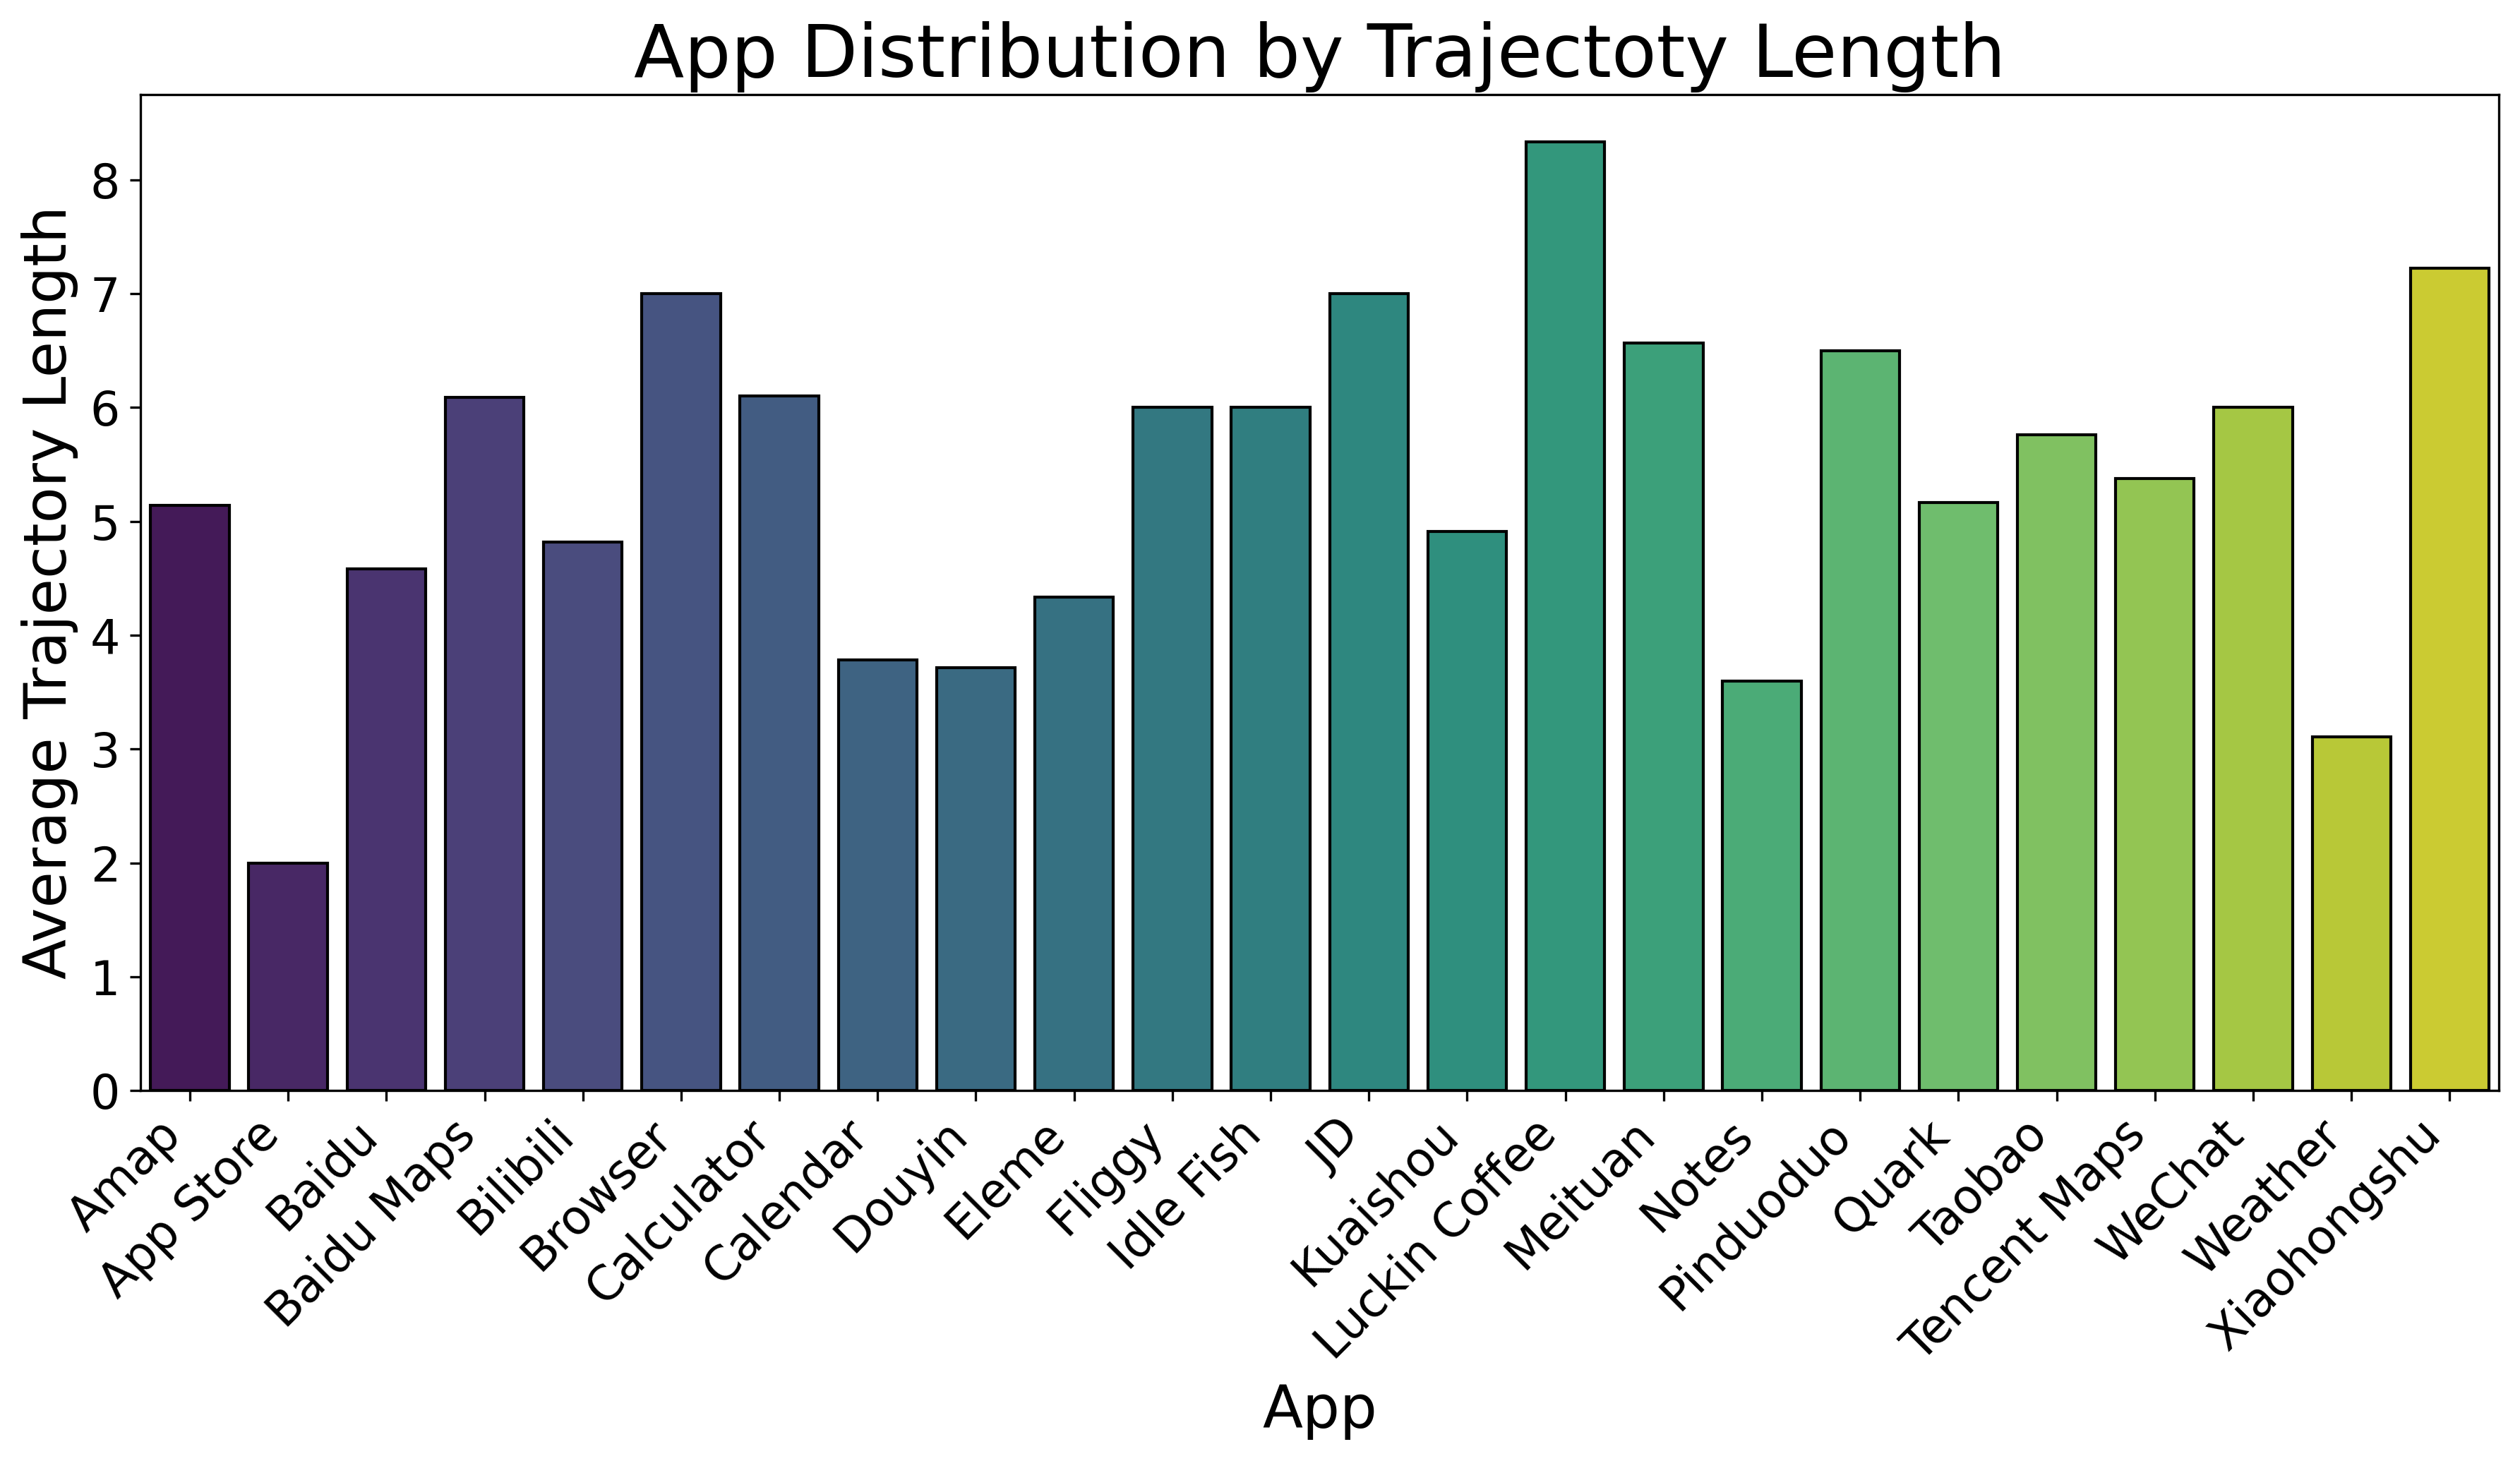

Overall trajectory_length statistics:
Average: 5.13265306122449, Min: 2, Max: 10
Open Source Data Num: 3924


In [5]:
open_data_path = "/Users/aiqihang/code/GUIAgent/data/open_source.jsonl"
open_source_data = read_jsonl(open_data_path)

for idx,data in enumerate(open_source_data):
    open_source_data[idx]['app'] = data['app_name']

trajectory_data = [data for data in open_source_data if is_trajectory_data_open(data['history'])]

# 将数据加载到 pandas DataFrame
df = pd.DataFrame(open_source_data)


# 根据映射字典替换 DataFrame 中的 中文 app_name 为英文名称
df['app'] = df['app'].map(app_name_mapping)

# 1. 根据 data_num 统计 app_name 的分布
app_distribution = df.groupby('app')['episode_length'].sum().reset_index()
app_distribution.columns = ['app_name', 'data num']
# app_distribution.to_csv("/home/aiqihang.aqh/GUI-R1/paper/open_app_datanum.csv")

print("App distribution based on data num:\n", app_distribution)

plt.figure(figsize=(12, 7), dpi=300)
palette = sns.color_palette("viridis", len(app_distribution))
sns.barplot(x=app_distribution['app_name'], y=app_distribution['data num'], palette=palette, edgecolor='black')

plt.xlabel('App', fontsize=20)
plt.ylabel('Data Count', fontsize=20)
plt.title('App Distribution by # of Data', fontsize=24)
plt.xticks(fontsize=16, rotation=45, ha='right')
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("/Users/aiqihang/code/GUIAgent/images/paper/open_app_datanum.png", dpi=300)
plt.show()



# 2. 根据 trajectory_num 统计 app_name 的分布
trajectory_df = pd.DataFrame(trajectory_data)

trajectory_df['app'] = trajectory_df['app'].map(app_name_mapping)
app_distribution = trajectory_df['app'].value_counts().reset_index()
app_distribution.columns = ['app_name', 'trajectory num']
print(f"total trajectory num: {app_distribution['trajectory num'].sum()}")

# 按字母顺序排序
app_distribution = app_distribution.sort_values(by='app_name').reset_index(drop=True)
# 按y值排序
# app_distribution = app_distribution.sort_values(by='count', ascending=False).reset_index(drop=True)

print("App distribution based on trajectory num:\n", app_distribution)

# 绘制 app 分布的柱状图
plt.figure(figsize=(12, 7), dpi=300)
palette = sns.color_palette("viridis", len(app_distribution))
sns.barplot(x=app_distribution['app_name'], y=app_distribution['trajectory num'], palette=palette, edgecolor='black')

plt.xlabel('App Name', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.title('App Distribution by # of Trajectory', fontsize=24)
plt.xticks(fontsize=16, rotation=45, ha='right')
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("/Users/aiqihang/code/GUIAgent/images/paper/open_app_trajectory_num.png", dpi=300)
plt.show()



# 3. 根据 trajectory_length 统计 app_name 的分布
app_stats = trajectory_df.groupby('app')['episode_length'].agg(['mean', 'min', 'max']).reset_index()

print("App distribution based on trajectory length:\n", app_stats)

plt.figure(figsize=(12, 7), dpi=300)
sns.barplot(x=app_stats['app'], y=app_stats['mean'], palette=palette, edgecolor='black')

plt.xlabel('App', fontsize=20)
plt.ylabel('Average Trajectory Length', fontsize=20)
plt.title('App Distribution by Trajectoty Length', fontsize=25)
plt.xticks(fontsize=16, rotation=45, ha='right')
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("/Users/aiqihang/code/GUIAgent/images/paper/open_app_trajectory_length.png", dpi=300)
plt.show()


# 3. 计算所有数据的平均 "episode_length", min, max
overall_avg = trajectory_df['episode_length'].mean()
overall_min = trajectory_df['episode_length'].min()
overall_max = trajectory_df['episode_length'].max()

print("Overall trajectory_length statistics:")
print(f"Average: {overall_avg}, Min: {overall_min}, Max: {overall_max}")

open_data_num = sum([data['episode_length'] for data in open_source_data])

print(f"Open Source Data Num: {open_data_num}")

,app_name,episode_id,episode_length,instruction,system,image_width,image_height,resize_width,resize_height,history,app
0,快手,63a08d3c-ff68-4b47-9a42-55d954aca47e,6,打开快手，搜索“周同学”并关注,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Kuaishou
1,小红书,2e88cb97-65ce-43a1-ba95-acdfe44247f1,4,打开小红书，浏览首页的笔记，给美女类的笔记点赞。,You are a mobile GUI agent. You are given a ta...,720,1280,728,1288,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Xiaohongshu
2,快手,2ef5d5ac-916b-41be-9861-2a2aceb0414a,6,打开快手，设置开启快手时默认静音,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Kuaishou
3,快手,aef823d2-322f-4568-8c49-2e433da27cc9,6,打开快手，设置开启快手时默认静音,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Kuaishou
4,快手,06baebab-618d-4b19-ab17-28963ab5346c,7,打开快手，设置开启快手时默认静音,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Kuaishou
...,...,...,...,...,...,...,...,...,...,...,...
289,夸克,dbd1b00a-59d4-4f64-86fd-9c52bb54db77,3,打开夸克，进入“我的”页面，点击登录夸克账号按钮,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Quark
290,夸克,cde98e7e-9d89-49d9-bb90-b8461f5413e0,6,打开夸克，搜索“PDF加水印”，使用第一个结果,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Quark
291,哔哩哔哩,32ce33aa-d289-4346-abef-0de68d00289e,7,去哔哩哔哩看李子柒的最新视频，并且点赞。,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Bilibili
292,哔哩哔哩,d5c5c12c-6901-4896-9cc5-325f5c9bd955,5,打开哔哩哔哩，搜索“机器之心官方”，找到up主并关注,You are a mobile GUI agent. You are given a ta...,1440,3200,672,1484,"[{'action': '{""name"": ""mobile_use"", ""arguments...",Bilibili
